In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("charts", exist_ok=True)

sentiment_d = pd.read_csv('fear_greed_index.csv')  ## reading files
trades_d = pd.read_csv('historical_data.csv')


# Data preparation
-Dataset Overview
-The following checks were performed:
- Number of rows and columns
- Missing values
- Duplicate records


In [21]:
summary_dp=pd.DataFrame ({"Data_set":["Sentiment","Trades"] , "Rows":[sentiment_d.shape[0],trades_d.shape[0]],"Columns":
                          [sentiment_d.shape[1],trades_d.shape[1]],"Missing Values":[sentiment_d.isnull().sum().sum(),
                                     trades_d.isnull().sum().sum()],"Duplicate_rows":[sentiment_d.duplicated().sum(),
                                                trades_d.duplicated().sum()]})

### Findings

- Sentiment_d dataset contains 2,644 rows and 4 columns.
- trades_d dataset contains 211,224 rows and 16 columns.
- No missing values were detected.
- No duplicate records were found.

# Timestamp Conversion and Date Alignment

The sentiment dataset contains daily sentiment labels, while the trade dataset contains 2  transaction timestamps.
To align both datasets, trade timestamps were converted to daily dates and sentiment date was also coverted to date dtype.
The range of the time was checked so as to ensure that both the dates align with each other.

In [24]:
sentiment_d.dtypes  #  checking the data_types
trades_d.dtypes
sentiment_d['date'] = pd.to_datetime(sentiment_d['date'])
sentiment_d['timestamp'] = pd.to_datetime(sentiment_d['date'])
trades_d['Timestamp IST'] = pd.to_datetime(trades_d['Timestamp IST'],dayfirst=True)
trades_d['Timestamp'] = pd.to_datetime(trades_d['Timestamp'],unit='ms')
print("Sentiment:")
print(sentiment_d['date'].min())
print(sentiment_d['date'].max())
print("Trades:")
print(trades_d['Timestamp IST'].min())
print(trades_d['Timestamp IST'].max())



Sentiment:
2018-02-01 00:00:00
2025-05-02 00:00:00
Trades:
2023-05-01 01:06:00
2025-05-01 12:13:00


## Key metrics
1) DAILY PNL PER TRADER/ACCOUNT
2)  WIN RATE
  --- we will be finding the  Percentage of trades that were profitable for each trader.
3) AVERAGE TRADE SIZE
   --we will be finding the average dollar amount traded per trader.
4) NUMBER OF TRADES PER DAY
5) Long / short ratio
   --The Long/Short Ratio measures whether traders are more bullish (long) or bearish (short).
6) Pnl votality
  -- How unstable the returns are


In [27]:
 trades_d['Date'] = trades_d['Timestamp IST'].dt.date
Daily_pnl = (trades_d.groupby(['Account','Date'])['Closed PnL'].sum().reset_index())
# ---------------------------------------------------------------------------------------------------------
trades_d['win_trade'] = (trades_d['Closed PnL'] > 0).astype(int)   # filtering # assigning 1 and 0 for positive n negative values.
win_rate = (trades_d.groupby('Account')['win_trade'].mean().mul(100).reset_index(name='win_rate_percent'))
# ---------------------------------------------------------------------------------------------------------
avg_trade_size = (trades_d.groupby('Account')['Size USD'].mean().reset_index(name='avg_trade_size'))
# ----------------------------------------------------------------------------------------------------------
trades_per_day=trades_d.groupby('Date')['Account'].count().reset_index(name='Trades_per_day')
# ----------------------------------------------------------------------------------------------------------
long_short_daily = (trades_d.groupby(['Date', 'Side']).size().unstack(fill_value=0))
long_short_daily['long_short_ratio'] = (long_short_daily['BUY'] /long_short_daily['SELL'])
# -----------------------------------------------------------------------------------------------------------
volatile=trades_d.groupby('Account')['Closed PnL'].std()
# ------------------------------------------------------------------------------------------------------------


In [31]:
trades_d['Date'] = pd.to_datetime(trades_d['Date'])

s_t_merge=trades_d.merge(sentiment_d ,how='left' ,left_on ='Date',right_on ='timestamp' )
## Merging the two datasets on date.

## PART B ) Analysis 
  ---Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [34]:
## PnL Analysis
trades_d['Date'] = pd.to_datetime(trades_d['Date'])
table1=s_t_merge.groupby('classification')['Closed PnL'].agg( ['mean','median','sum'])


# OUTPUT
# Comparing the two primary sentiment categories, traders generated a higher average PnL on Fear days (54.29) than on Greed days (42.74). This suggests that trading performance was relatively stronger during periods of market fear than during periods of optimism.
# The median PnL was 0 for all groups. This indicates a highly skewed distribution in which a relatively small number of profitable trades contributed disproportionately to overall profitability.
# Most trades: small loss / break-even
# A few trades: very large profits
# Those few big wins are responsible for most of the total profit

In [37]:
# Win_rate analysis
table2=s_t_merge.groupby('classification')['win_trade'].mean() * 100

# OUTPUT
# Traders achieved a higher win rate during Fear periods (42.08%) compared to Greed periods (38.48%). This indicates that trades executed during fearful market conditions were more likely to be profitable.

In [40]:
#  Drawdown analysis
# Drawdown is a measure of how much money a trader loses from a peak before recovering.
Daily_pnl = (s_t_merge.groupby(['Account','Date','classification'])['Closed PnL'].sum().reset_index())
Daily_pnl.groupby('classification')['Closed PnL'].min()

classification
Extreme Fear     -77308.420095
Extreme Greed   -132271.000000
Fear            -108604.496278
Greed           -358963.139984
Neutral         -113601.020138
Name: Closed PnL, dtype: float64

# OUTPUT
# The largest loss occurred during Greed periods (-358,963), substantially  exceeding the worst losses observed during Fear (-108,604)
 # This suggests that traders were exposed to significantly greater downside risk during optimistic market conditions.

# Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
#Yes
#PnL: Average PnL was higher on Fear days (54.29) than on Greed days (42.74), indicating better average profitability during fearful market conditions.
#Win Rate: Traders achieved a higher win rate on Fear days (42.08%) compared to Greed days (38.48%), suggesting a greater proportion of profitable 
#trades during periods of market fear.
#Drawdown Proxy: The worst observed daily loss was substantially larger during Greed periods (-358,963) than during Fear periods (-108,604),
#indicating greater downside risk when market sentiment was optimistic.

# Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [45]:
# TRADE FREQUENCY ANALYSIS
daily_trade_freq = (s_t_merge.groupby(['Date','classification']).size().reset_index(name='trade_count'))
table3=daily_trade_freq.groupby('classification')['trade_count'].mean()

# OUTPUT
## Comparing the two primary sentiment categories, average trading activity during Fear periods (679.53 trades) was more than double that observed during Greed periods (260.64 trades). This indicates that traders were substantially more active during fearful market conditions.

In [48]:
# POSITION SIZE ANALYSIS
traded_value=s_t_merge.groupby('classification')['Size USD'].mean()

# Position Size Behavior: Traders adjusted their position sizes based on market sentiment. The largest average trade sizes were observed during Fear (7,816 USD) and Greed (5,737 USD) periods, while the smallest position sizes occurred during Extreme Greed (3,112 USD) conditions. This indicates that traders did not uniformly increase risk exposure during optimistic markets. Instead, position sizing was higher during Fear conditions, suggesting that traders may view market downturns as opportunities to deploy larger capital.

In [51]:
#LONG-SHORT BIAS ANALYSIS

table4=pd.crosstab(s_t_merge['classification'],s_t_merge['Side'],normalize='index') * 100

# OUTPUT
#  Long/Short Bias Analysis:
# Traders exhibited varying directional bias across sentiment regimes. During Extreme Fear, traders showed a slight long bias (51.10% BUY vs 48.90% SELL), suggesting potential  buying during market downturns. In contrast, during Greed and Extreme Greed periods, traders shifted toward a short bias, with SELL trades exceeding BUY trades (55.14% SELL in Extreme Greed). This indicates that traders were more inclined to take bearish positions during optimistic market conditions, possibly anticipating reversals.

## Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

# Yes, traders change behavior based on sentiment. They trade more and take larger positions during Fear periods, while reducing activity during Greed # periods. They also show a contrarian bias, going slightly long in Fear and more short in Greed/Extreme Greed conditions.

In [55]:
# Identify 2–3 segments (examples):
# Frequent vs infrequent traders
# Consistent winners vs inconsistent traders
# High size trader vs Low size traders

trade_freq = (s_t_merge.groupby('Account').size().reset_index(name='total_trades'))
median_val = trade_freq['total_trades'].median()
trade_freq['segment'] = trade_freq['total_trades'].apply(lambda x: 'Frequent' if x >= median_val else 'Infrequent')


In [56]:
win_rate = (s_t_merge.groupby('Account')['win_trade'].mean().reset_index(name='win_rate'))
win_rate['segment'] = win_rate['win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 0.55 else 'Inconsistent')

In [59]:
size_seg = (s_t_merge.groupby('Account')['Size USD'].mean().reset_index(name='avg_size'))
threshold = size_seg['avg_size'].median()

size_seg['segment'] = size_seg['avg_size'].apply(
    lambda x: 'High Size Trader' if x >= threshold else 'Low Size Trader')

## Insights
 1: Performance differs across sentiment regimes
 Traders performed better during Fear periods compared to Greed periods. Both average PnL and win rate were higher in Fear conditions, indicating that traders were more profitable during pessimistic market sentiment. This suggests that traders may be more disciplined or selective during Fear, while performance weakens during Greed.
 

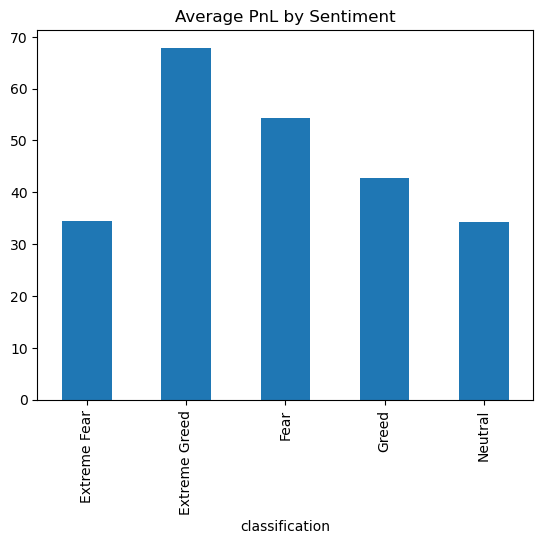

In [62]:
import matplotlib.pyplot as plt
s_t_merge.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.savefig("charts/Av_pnl_by_sentiment.png")

plt.show()

# Insight 2: Traders take larger positions during Fear (counter-intuitive behavior)
Position sizing is highest during Fear and lowest during Extreme Greed. This indicates a counter-cyclical behavior where traders deploy more capital during market downturns, possibly treating dips as buying opportunities. In contrast, during Greed phases, traders reduce position sizes, suggesting caution or profit-taking behavior.


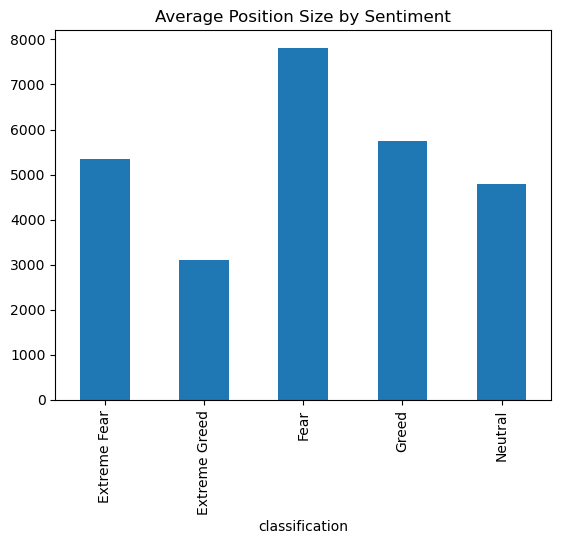

In [64]:
s_t_merge.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title("Average Position Size by Sentiment")
plt.savefig("charts/Avg_Position_Size_by_sentiment.png")

plt.show()

3: Traders show contrarian long/short bias
# Traders exhibit a mildly contrarian directional bias. During Fear, BUY activity is relatively higher, while during Greed and Extreme Greed, SELL activity dominates. This suggests that traders may be positioning for reversals rather than following sentiment trends.

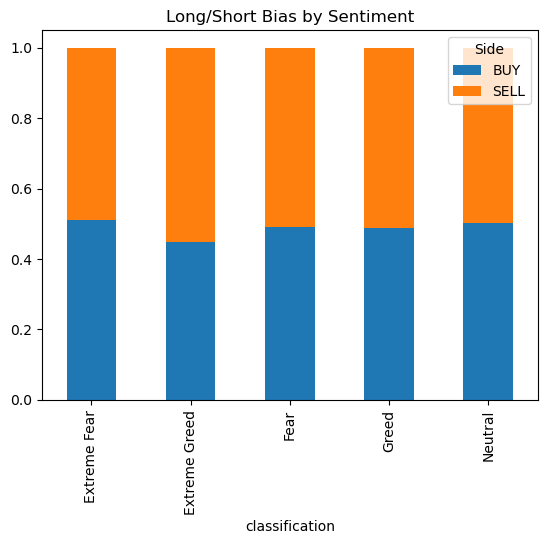

In [66]:
import pandas as pd

pd.crosstab(s_t_merge['classification'],s_t_merge['Side'],normalize='index').plot(kind='bar', stacked=True)

plt.title("Long/Short Bias by Sentiment")
plt.savefig("charts/Bias_by_sentiment.png")


plt.show()

# Strategy 1: Fear-based momentum participation strategy
During Fear and Extreme Fear regimes, traders show higher win rates and increased trading activity. A potential strategy is to increase market participation during these periods, particularly for frequent and historically consistent winning traders. However, risk should still be controlled by limiting excessive position concentration. This approach leverages higher observed profitability during pessimistic sentiment while avoiding overexposure.

# Strategy 2: Greed-phase risk reduction strategy
During Greed and Extreme Greed periods, traders exhibit lower win rates and significantly higher downside risk (large drawdowns). A risk-managed approach would involve reducing position sizes and limiting trade frequency during these phases. Traders may also consider taking profits or adopting a more defensive stance, as market conditions appear more prone to reversals and losses during optimistic sentiment.

# Strategy 3: Segment-based execution

Different trader types should behave differently:

Frequent traders → active during Fear only
Infrequent traders → avoid Greed trading altogether
High-size traders → scale down during Extreme Greed

In [68]:
## Predictive model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

s_t_merge['date'] = pd.to_datetime(s_t_merge['Timestamp IST']).dt.date
daily = s_t_merge.groupby(['Account', 'date']).agg(pnl=('Closed PnL', 'sum'),trades=('Trade ID', 'count'),avg_trade_size=('Size USD', 'mean'),
                                                   win_rate=('win_trade', 'mean')).reset_index()
daily = daily.sort_values(['Account', 'date'])
daily['next_day_pnl'] = daily.groupby('Account')['pnl'].shift(-1)
daily['target'] = (daily['next_day_pnl'] > 0).astype(int)
daily = daily.dropna()
if 'classification' in s_t_merge.columns:
    sentiment = s_t_merge[['date','classification']].drop_duplicates()
    daily = daily.merge(sentiment, on='date', how='left')
    daily = pd.get_dummies(daily, columns=['classification'], drop_first=True)
X = daily.drop(columns=['Account','date','target','next_day_pnl'])
y = daily['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6038961038961039


C:\Users\navha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


            avg_pnl  total_trades  avg_trade_size  win_rate
cluster                                                    
0         49.302560   7421.166667     3548.222060  0.415283
1        365.725364   1691.600000     6619.420645  0.346208
2         38.024405   8219.333333    24666.435723  0.400056


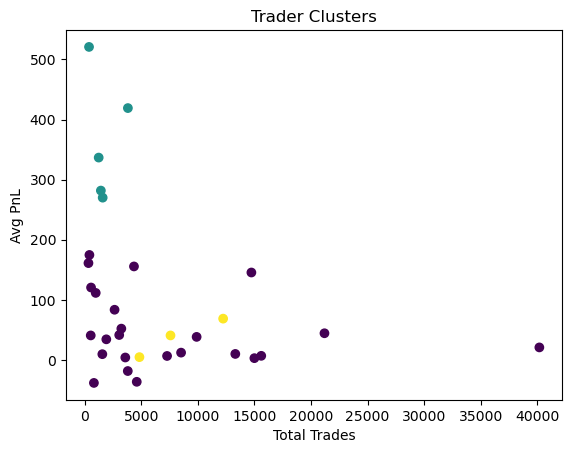

In [69]:
# Clustering
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
cluster_data = s_t_merge.groupby('Account').agg(avg_pnl=('Closed PnL', 'mean'),total_trades=('Trade ID', 'count'),avg_trade_size=('Size USD', 'mean'),
    win_rate=('win_trade', 'mean')).reset_index()

X = cluster_data.drop(columns=['Account'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = cluster_data.groupby('cluster')[['avg_pnl', 'total_trades','avg_trade_size', 'win_rate']].mean()
print(cluster_summary)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(cluster_data['total_trades'],cluster_data['avg_pnl'],c=cluster_data['cluster'])
plt.xlabel("Total Trades")
plt.ylabel("Avg PnL")
plt.title("Trader Clusters")
plt.savefig("charts/Trader_Clusters.png")
plt.show()
cluster_data.to_csv("cluster_data.csv", index=False)

In [70]:
##  streamlit code
import streamlit as st
import pandas as pd
df = pd.read_csv("cluster_data.csv")
st.title("Trader Dashboard")
st.dataframe(df.head())
summary = df.groupby("cluster").mean(numeric_only=True)
st.subheader("Cluster Summary")
st.dataframe(summary)
st.bar_chart(summary["avg_pnl"])

2026-06-02 11:45:59.797 
  command:

    streamlit run C:\Users\navha\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()